In [5]:
import fastf1
import matplotlib.pyplot as plt
import pandas as pd

# Disable cache to avoid directory issues
fastf1.Cache.clear_cache()

In [7]:
# Load session
session = fastf1.get_session(2024, 'Monaco', 'Q')
session.load()
print(f"Session loaded: {session.event['EventName']} - 2024")

core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '55', '4', '63', '1', '44', '22', '23', '10', '31', '3', '18', '27', '14', '2', '20', '11', '77', '24']


Session loaded: Monaco Grand Prix - 2024


In [9]:
# Get telemetry for multiple drivers
drivers = ['VER', 'LEC', 'SAI']
telemetries = {}

for driver in drivers:
    lap = session.laps.pick_drivers(driver).pick_fastest()
    telemetries[driver] = lap.get_telemetry()
    print(f"{driver}: Lap time {lap['LapTime']}")

VER: Lap time 0 days 00:01:10.567000
LEC: Lap time 0 days 00:01:10.270000
SAI: Lap time 0 days 00:01:10.518000


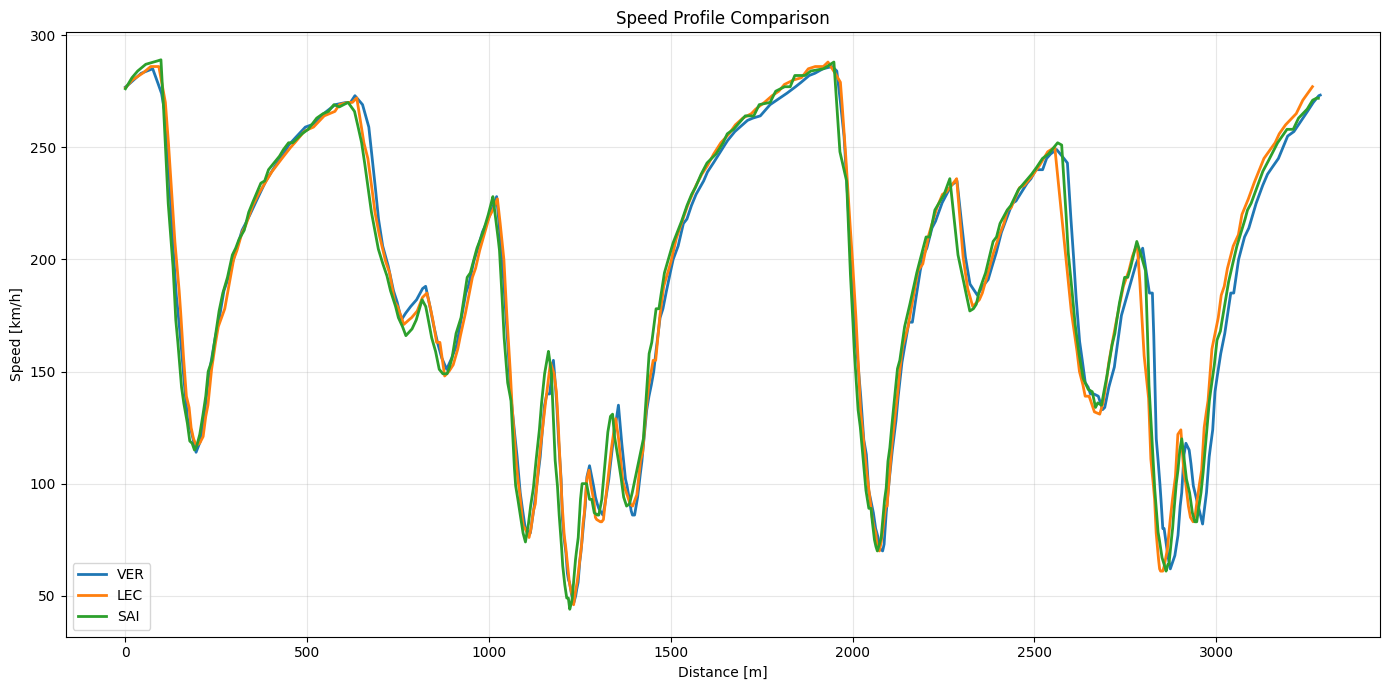

In [10]:
# Plot speed comparison
plt.figure(figsize=(14, 7))
for driver, tel in telemetries.items():
    plt.plot(tel['Distance'], tel['Speed'], label=driver, linewidth=2)

plt.xlabel('Distance [m]')
plt.ylabel('Speed [km/h]')
plt.title('Speed Profile Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

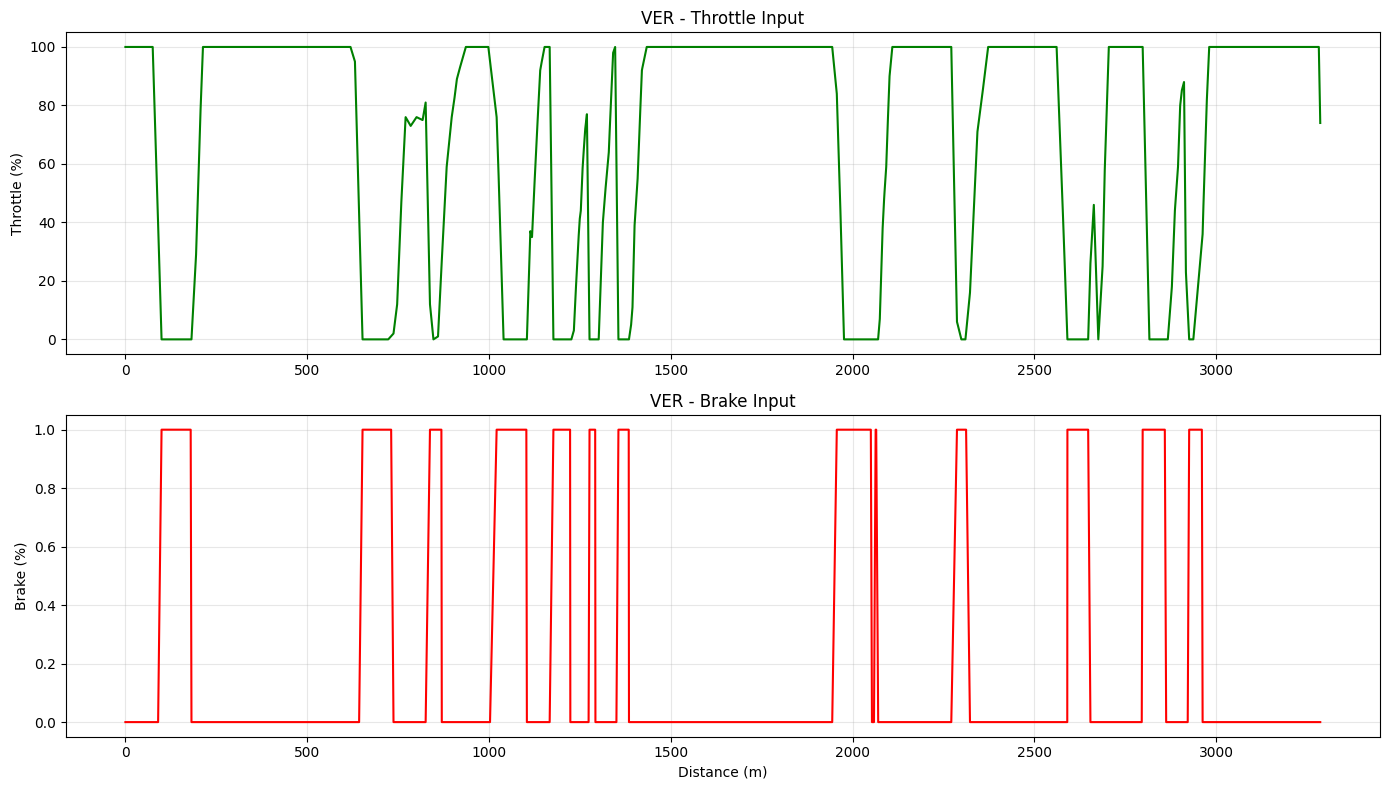

In [11]:
# Analyze throttle & brake for one driver
driver = 'VER'
tel = telemetries[driver]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

ax1.plot(tel['Distance'], tel['Throttle'], label='Throttle', color='green')
ax1.set_ylabel('Throttle (%)')
ax1.set_title(f'{driver} - Throttle Input')
ax1.grid(True, alpha=0.3)

ax2.plot(tel['Distance'], tel['Brake'], label='Brake', color='red')
ax2.set_ylabel('Brake (%)')
ax2.set_xlabel('Distance (m)')
ax2.set_title(f'{driver} - Brake Input')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

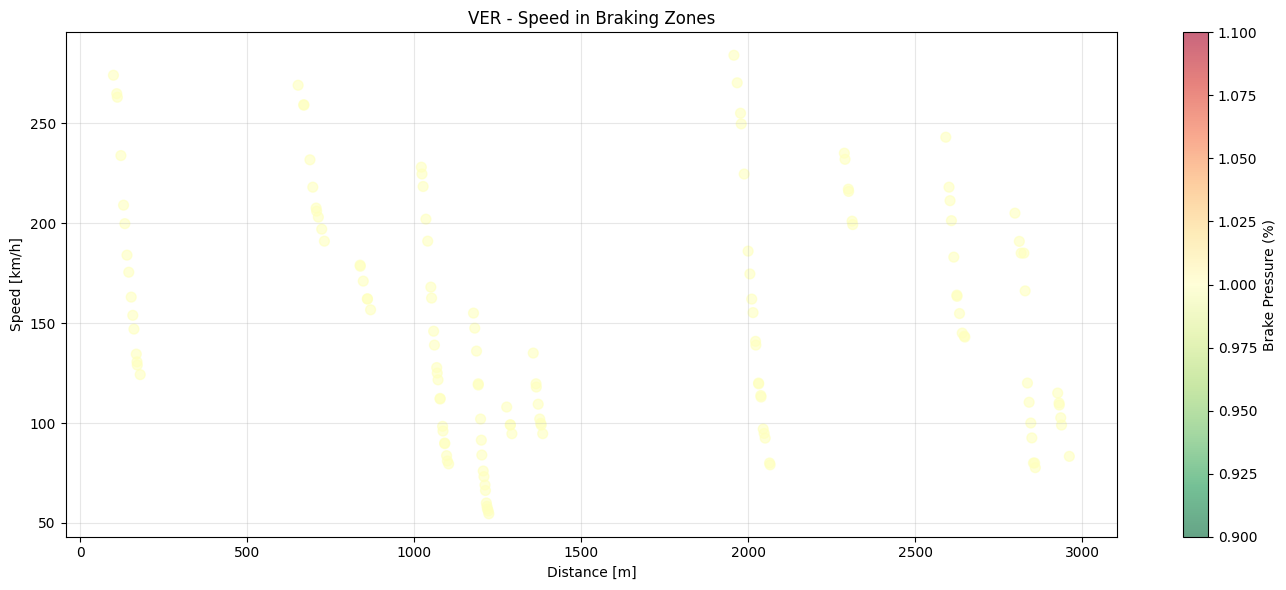

In [12]:
# Advanced: Find braking zones
driver = 'VER'
tel = telemetries[driver]

# Find corners (where brake is pressed)
braking_points = tel[tel['Brake'] > 0]

fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(braking_points['Distance'], braking_points['Speed'], 
           c=braking_points['Brake'], cmap='RdYlGn_r', s=50, alpha=0.6)
ax.set_xlabel('Distance [m]')
ax.set_ylabel('Speed [km/h]')
ax.set_title(f'{driver} - Speed in Braking Zones')
cbar = plt.colorbar(ax.collections[0])
cbar.set_label('Brake Pressure (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()